In [690]:
pip install pandas numpy scikit-learn matplotlib seaborn sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [691]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [692]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [693]:
# koneksi ke database mysql
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = int(os.getenv('DB_PORT', '3306'))
DB_USER     = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME     = os.getenv('DB_NAME', 'datawarehouse_om')

# engine koneksi (SQLAlchemy)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"Koneksi ke database siap: {DB_HOST}:{DB_PORT}/{DB_NAME}")

Koneksi ke database siap: localhost:3306/datawarehouse_om


In [694]:
query = """
    SELECT
        f.fact_id,
        f.severity,
        m.scope_of_work,
        s.city,
        t.month
    FROM fact_maintenance_activity f
    JOIN dim_maintenance_type m ON f.maintenance_id = m.maintenance_id
    JOIN dim_site             s ON f.site_id        = s.site_id
    JOIN dim_time             t ON f.time_id        = t.time_id
"""

df = pd.read_sql(query, con=engine)
print(f"Data berhasil diambil. Total baris: {df.shape[0]}, Kolom: {df.shape[1]}")
print(df.head())

Data berhasil diambil. Total baris: 45050, Kolom: 5
   fact_id severity scope_of_work                 city  month
0    20325    major           gne   kabupaten lumajang      5
1    20437    major           gne   kabupaten lamongan      6
2    20476    major           gne  kabupaten pamekasan      6
3    20496    major           gne  kabupaten situbondo      6
4    20503    major           gne    kabupaten sumenep      6


In [695]:
# PRE PROCESSING
if 'fact_id' in df.columns:
    df.drop(columns=['fact_id'], inplace=True)
    
print(f"Jumlah nilai null per kolom:\n{df.isnull().sum()}")
df.dropna(inplace=True)
print(f"\nDistribusi severity:")
print(df['severity'].value_counts())

Jumlah nilai null per kolom:
severity         0
scope_of_work    0
city             0
month            0
dtype: int64

Distribusi severity:
severity
minor    41401
major     3649
Name: count, dtype: int64


In [696]:
# encoding
le_scope = LabelEncoder()
df['scope_of_work'] = le_scope.fit_transform(df['scope_of_work'].astype(str))
print(f"Encoding scope_of_work: {len(le_scope.classes_)} kelas unik")

le_city = LabelEncoder()
df['city'] = le_city.fit_transform(df['city'].astype(str))
print(f"Encoding city: {len(le_city.classes_)} kelas unik")

severity_raw = df['severity'].astype(str).str.strip().str.lower()
severity_map = {'minor': 0, 'major': 1, '0': 0, '1': 1}
df['severity'] = severity_raw.map(severity_map)

# supaya tidak ada severity yang gagal di-map
if df['severity'].isnull().sum() > 0:
    print(f"WARNING: {df['severity'].isnull().sum()} baris severity tidak ter-map!")
    print(f"Nilai unik yang bermasalah: {severity_raw[df['severity'].isnull()].unique()}")
else:
    print("Semua severity berhasil di-map.")

df['severity'] = df['severity'].astype(int)
print("\nEncoding severity: {'minor': 0, 'major': 1}")
print(f"\nDistribusi severity (encoded):\n{df['severity'].value_counts()}")

Encoding scope_of_work: 52 kelas unik
Encoding city: 31 kelas unik
Semua severity berhasil di-map.

Encoding severity: {'minor': 0, 'major': 1}

Distribusi severity (encoded):
severity
0    41401
1     3649
Name: count, dtype: int64


In [697]:
# MODELING
FEATURE_COLS = [
    'scope_of_work',
    'city',
    'month',
]

X = df[FEATURE_COLS]   # variabel independen (X)
y = df['severity']     # variabel dependen (Y)

print(f"Fitur (X): {list(X.columns)}")
print(f"Target (y): severity | Shape: {y.shape}")

Fitur (X): ['scope_of_work', 'city', 'month']
Target (y): severity | Shape: (45050,)


In [698]:
# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # proporsi agar kelas seimbang
)
 
print(f"Data berhasil di split:")
print(f"- Training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"- Testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

Data berhasil di split:
- Training : 36040 baris (80.0%)
- Testing  : 9010 baris (20.0%)


In [699]:
# random forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,               # jumlah pohon keputusan
    random_state=42,                # seed
    class_weight={0: 1, 1: 4},      # Major 4x lebih penting dari minor
    n_jobs=-1                       # gunakan semua core CPU
)

# training
rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih.")

# testing
y_pred = rf_model.predict(X_test)
print("\nPrediksi pada data testing selesai.")

Model Random Forest berhasil dilatih.

Prediksi pada data testing selesai.


In [700]:
# EVALUASI MODEL
class_names = ['minor', 'major']  # decode severity (0 minor, 1 major) 
 
# metrik evaluasi
acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred, average='weighted')
rec       = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
cm        = confusion_matrix(y_test, y_pred)
 
print("\n" + "="*55)
print("          HASIL EVALUASI MODEL RANDOM FOREST")
print("="*55)
print(f" Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f" Precision : {prec:.4f}  (weighted avg)")
print(f" Recall    : {rec:.4f}  (weighted avg)")
print(f" F1-Score  : {f1:.4f}  (weighted avg)")
print("="*55)
 
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=class_names))


          HASIL EVALUASI MODEL RANDOM FOREST
 Accuracy  : 0.9484  (94.84%)
 Precision : 0.9460  (weighted avg)
 Recall    : 0.9484  (weighted avg)
 F1-Score  : 0.9470  (weighted avg)
Classification Report:
              precision    recall  f1-score   support

       minor       0.97      0.98      0.97      8280
       major       0.70      0.63      0.66       730

    accuracy                           0.95      9010
   macro avg       0.84      0.80      0.82      9010
weighted avg       0.95      0.95      0.95      9010



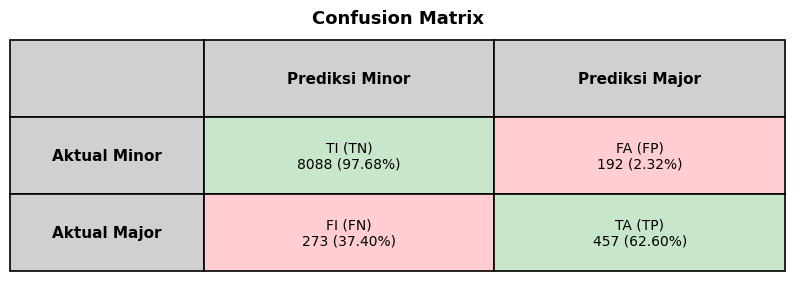

In [701]:
# confusion matrix (visualisasi)
TN = cm[0][0]  # minor -> minor
FP = cm[0][1]  # minor -> major
FN = cm[1][0]  # major -> minor
TP = cm[1][1]  # major -> major

total_minor = TN + FP
total_major = FN + TP

TN_pct = TN / total_minor * 100
FP_pct = FP / total_minor * 100
FN_pct = FN / total_major * 100
TP_pct = TP / total_major * 100

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table_data = [
    ['',              'Prediksi Minor',               'Prediksi Major'             ],
    ['Aktual Minor',  f'TI (TN)\n{TN} ({TN_pct:.2f}%)', f'FA (FP)\n{FP} ({FP_pct:.2f}%)'],
    ['Aktual Major',  f'FI (FN)\n{FN} ({FN_pct:.2f}%)', f'TA (TP)\n{TP} ({TP_pct:.2f}%)'],
]

table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1] 
)

table.auto_set_font_size(False)
table.set_fontsize(11)

col_widths = [0.25, 0.375, 0.375]
for (row, col), cell in table.get_celld().items():
    cell.set_width(col_widths[col])
    cell.set_height(0.33)
    cell.set_edgecolor('black')
    cell.set_linewidth(1.2)

    if row == 0 or col == 0:
        cell.set_facecolor('#D0D0D0')
        cell.set_text_props(fontweight='bold', fontsize=11)
    elif row == 1 and col == 1:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    elif row == 2 and col == 2:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    else:
        cell.set_facecolor('#FFCDD2')
        cell.set_text_props(fontsize=10)

ax.set_title('Confusion Matrix',
             fontsize=13, fontweight='bold', pad=12)
plt.show()

In [702]:
# feature importance
feature_importances = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
 
print("Feature Importance (diurutkan dari yang paling berpengaruh):")
for i, row in feature_importances.iterrows():
    bar = "█" * int(row['Importance'] * 50)
    print(f" {i+1:2}. {row['Feature']:<20} {row['Importance']:.4f}  {bar}")

Feature Importance (diurutkan dari yang paling berpengaruh):
  1. scope_of_work        0.7397  ████████████████████████████████████
  2. month                0.1397  ██████
  3. city                 0.1206  ██████


In [703]:
# insights
top_feature = feature_importances.iloc[0]['Feature']
top_score   = feature_importances.iloc[0]['Importance']
top3        = feature_importances.head(3)['Feature'].tolist()
 
print("INSIGHT MODEL:")
print(f"1) Fitur paling berpengaruh : {top_feature} ({top_score:.4f})")
print(f"2) Top 3 fitur              : {', '.join(top3)}")
print(f"3) Akurasi model            : {acc*100:.2f}%")
print(f"4) F1-Score (weighted)      : {f1:.4f}")
 
if acc >= 0.90:
    print("\nModel memiliki performa SANGAT BAIK (Accuracy ≥ 90%)")
elif acc >= 0.80:
    print("\nModel memiliki performa BAIK (Accuracy ≥ 80%)")
elif acc >= 0.70:
    print("\nModel memiliki performa CUKUP (Accuracy ≥ 70%)")
else:
    print("\nModel perlu perbaikan (Accuracy < 70%)")

INSIGHT MODEL:
1) Fitur paling berpengaruh : scope_of_work (0.7397)
2) Top 3 fitur              : scope_of_work, month, city
3) Akurasi model            : 94.84%
4) F1-Score (weighted)      : 0.9470

Model memiliki performa SANGAT BAIK (Accuracy ≥ 90%)
